In [15]:
import sys, os
_base = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(_base, 'kepler-mapper'))
sys.path.insert(0, os.path.join(_base, 'mealpy'))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from smapper_utils import run_optimization, draw_graph, SEED, EPOCH, POP_SIZE

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import kmapper as km
import kmapper.evaluate as evaluate
from sklearn import cluster
import sklearn

In [17]:
# Download cat mesh from:
# https://people.csail.mit.edu/sumner/research/deftransfer/data.html
# Place cat-reference.obj in this directory.

def load_obj(obj_path):
    points = []
    with open(obj_path) as f:
        for line in f:
            parts = line.split()
            if parts and parts[0] == "v":
                points.append([float(x) for x in parts[1:4]])
    return np.array(points)

cat_data = load_obj('cat-reference.obj')

In [18]:
data = cat_data
mapper = km.KeplerMapper(verbose=0)
projected_data = mapper.fit_transform(data)

In [ ]:
def objective_function(X):
    n = int(round(float(X[0])))
    a = float(X[1])
    try:
        cover = km.Cover(n_cubes=n, perc_overlap=a)
        graph = mapper.map(projected_data, data,
                           clusterer=cluster.DBSCAN(eps=0.1, min_samples=5),
                           cover=cover)
        tsc = evaluate.compute_SC_adj(data, projected_data, graph, cover,
                                      type='k', cluster=cluster.DBSCAN(eps=0.1, min_samples=5))
        return -tsc
    except Exception:
        return 3.0

problem = {
    "obj_func": objective_function,
    "bounds": [
        {"name": "n", "lb": 7, "ub": 25},
        {"name": "a", "lb": 0.1, "ub": 0.7},
    ],
    "minmax": "min",
}

from mealpy import FloatVar
problem["bounds"] = [FloatVar(lb=7, ub=25, name="n"), FloatVar(lb=0.1, ub=0.7, name="a")]
results = run_optimization(problem, 'results_output_cat.txt')

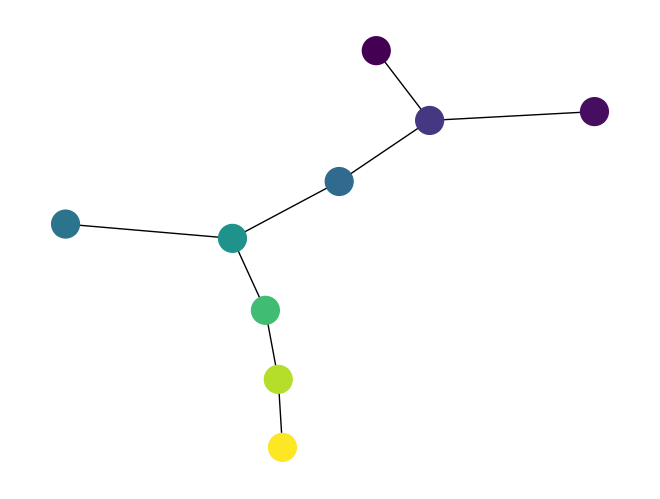

100%|██████████| 100/100 [00:04<00:00, 21.18it/s]


SC:0.180609045
SC_norm:0.5903045225
TSR:1.0
SC_adj:0.7951522612499999


0.7951522612499999

In [20]:
n, a = 7, 0.1
cover = km.Cover(n_cubes=n, perc_overlap=a)
graph = mapper.map(projected_data, data, clusterer=cluster.DBSCAN(eps=0.1, min_samples=5), cover=cover)
draw_graph(graph, projected_data, 'cat.png')
evaluate.compute_SC_adj(data, projected_data, graph, cover,
                        type='k', cluster=cluster.DBSCAN(eps=0.1, min_samples=5))

# Mapper

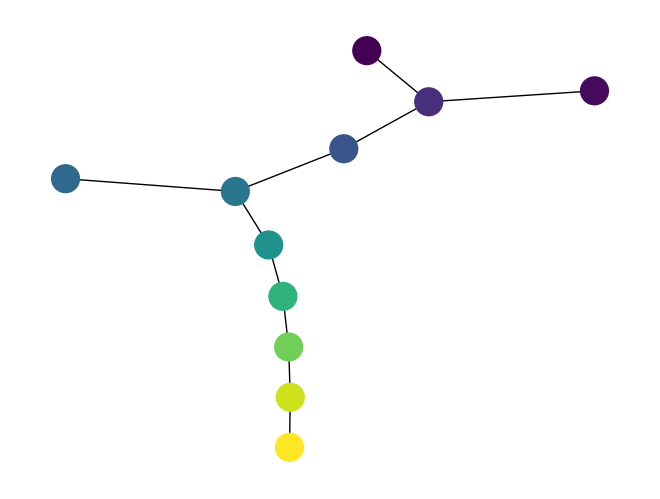

100%|██████████| 100/100 [00:04<00:00, 20.43it/s]


SC:-0.00199550014
SC_norm:0.49900224993
TSR:1.0
SC_adj:0.749501124965


0.749501124965

In [21]:
n, a = 9, 0.2
cover = km.Cover(n_cubes=n, perc_overlap=a)
graph = mapper.map(projected_data, data, clusterer=cluster.DBSCAN(eps=0.1, min_samples=5), cover=cover)
draw_graph(graph, projected_data, 'cat.png')
evaluate.compute_SC_adj(data, projected_data, graph, cover,
                        type='k', cluster=cluster.DBSCAN(eps=0.1, min_samples=5))

## D-Mapper

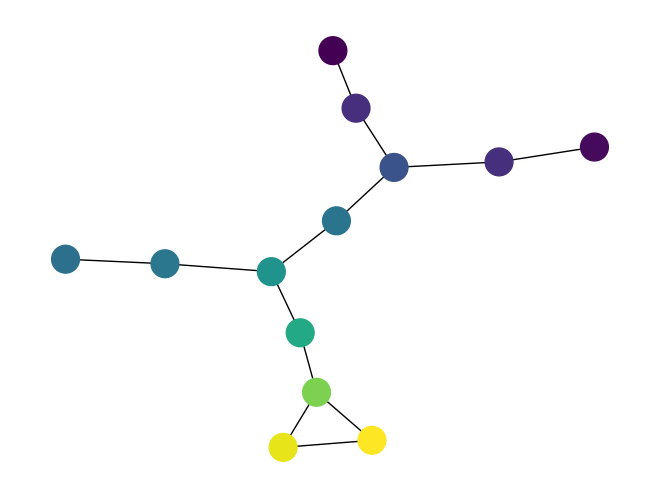

100%|██████████| 100/100 [00:25<00:00,  3.86it/s]


SC:0.0221917942833
SC_norm:0.51109589714165
TSR:1.0
SC_adj:0.755547948570825


0.755547948570825

In [22]:
mapper_d = km.D_Mapper(verbose=0)
n, a = 9, 0.01
cover_d = km.D_Cover(n_cubes=n, alpha=a, max_iter=100000, n_init=10, verbose=0)
graphD = mapper_d.map(projected_data, data,
                      clusterer=cluster.DBSCAN(eps=0.1, min_samples=5), cover=cover_d)
draw_graph(graphD, projected_data, 'catg.png')
evaluate.compute_SC_adj(data, projected_data, graphD,
                        km.D_Cover(n_cubes=n, alpha=a, max_iter=100000, n_init=10, verbose=0),
                        type='d', cluster=cluster.DBSCAN(eps=0.1, min_samples=5))